# 

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
from influxdb_client import InfluxDBClient
import os
from dotenv import load_dotenv
from influxdb_client import InfluxDBClient

load_dotenv()

INFLUX_URL = os.getenv("INFLUX_URL", "http://localhost:8086")
INFLUX_TOKEN = os.getenv("INFLUX_TOKEN")
INFLUX_ORG = os.getenv("INFLUX_ORG", "casa")
INFLUX_BUCKET = os.getenv("INFLUX_BUCKET", "monitoraggio_pi")


if not INFLUX_TOKEN:
    print("Errore: INFLUX_TOKEN non trovato! WTF .env.")
else:
    print(f" Configurazione caricata correttamente!")
    print(f" URL: {INFLUX_URL} |  Bucket: {INFLUX_BUCKET}")
    
# Inizializza il client
client = InfluxDBClient(url=INFLUX_URL, token=INFLUX_TOKEN, org=INFLUX_ORG)
query_api = client.query_api()

# query Flux (prendiamo l'ultima ora di dati)
query = f'''
from(bucket: "{INFLUX_BUCKET}")
  |> range(start: -1h)
  |> filter(fn: (r) => r["_measurement"] == "ambiente")
'''

df = query_api.query_data_frame(query)

# Chiudi la connessione
client.close()

df.head()


 Configurazione caricata correttamente!
 URL: http://10.26.169.209:8086 |  Bucket: monitoraggio_pi


/home/linkyolo/anaconda3/lib/python3.13/site-packages/influxdb_client/client/warnings.py:31: MissingPivotFunction: The query doesn't contains the pivot() function.

The result will not be shaped to optimal processing by pandas.DataFrame. Use the pivot() function by:

    
from(bucket: "monitoraggio_pi")
  |> range(start: -1h)
  |> filter(fn: (r) => r["_measurement"] == "ambiente")
 |> pivot(rowKey:["_time"], columnKey: ["_field"], valueColumn: "_value")

You can disable this warning by:
    import warnings
    from influxdb_client.client.warnings import MissingPivotFunction

    warnings.simplefilter("ignore", MissingPivotFunction)

For more info see:
    - https://docs.influxdata.com/resources/videos/pivots-in-flux/
    - https://docs.influxdata.com/flux/latest/stdlib/universe/pivot/
    - https://docs.influxdata.com/flux/latest/stdlib/influxdata/influxdb/schema/fieldsascols/

  warnings.warn(message, MissingPivotFunction)


,result,table,_start,_stop,_time,_value,_field,_measurement,host,stanza
0,_result,0,2026-07-09 16:26:41.976291+00:00,2026-07-09 17:26:41.976291+00:00,2026-07-09 16:26:44.808403+00:00,33.7,percepita,ambiente,raspberry_pi_4,camera
1,_result,0,2026-07-09 16:26:41.976291+00:00,2026-07-09 17:26:41.976291+00:00,2026-07-09 16:26:50.078660+00:00,33.7,percepita,ambiente,raspberry_pi_4,camera
2,_result,0,2026-07-09 16:26:41.976291+00:00,2026-07-09 17:26:41.976291+00:00,2026-07-09 16:26:55.338953+00:00,33.7,percepita,ambiente,raspberry_pi_4,camera
3,_result,0,2026-07-09 16:26:41.976291+00:00,2026-07-09 17:26:41.976291+00:00,2026-07-09 16:27:00.609731+00:00,33.7,percepita,ambiente,raspberry_pi_4,camera
4,_result,0,2026-07-09 16:26:41.976291+00:00,2026-07-09 17:26:41.976291+00:00,2026-07-09 16:27:05.869921+00:00,33.7,percepita,ambiente,raspberry_pi_4,camera


In [27]:
df["fan"] = "ON"
df["fan-direction"] = "OUTSIDE"
df["door"] = "OPEN"
df["meteo"] = 32

In [22]:
df.count()

result           1950
table            1950
_start           1950
_stop            1950
_time            1950
_value           1950
_field           1950
_measurement     1950
host             1950
stanza           1950
fan              1950
fan-direction    1950
door             1950
meteo            1950
dtype: int64

In [13]:
df.to_csv("fan_off") #18.11

In [23]:
#2026-07-09 18:57:00,122 [INFO] Sistema -> CPU:0.2% Temp:62.8°C RAM:25.2
df.to_csv("fan_on_door_closed")

In [ ]:
#2026-07-09 19:25:27,361 [INFO] Ambiente -> T:33.9°C U:33% P:33.7°C
df.to_csv("fan_on_door_open")

In [87]:
#Clean data
import pandas as pd
fan_off = pd.read_csv("fan_off")
fan_on_door_closed = pd.read_csv("fan_on_door_closed")
fan_on_door_open = pd.read_csv("fan_on_door_open")

In [88]:
fan_off.tail()

,Unnamed: 0,result,table,_start,_stop,_time,_value,_field,_measurement,host,stanza,fan,meteo
460,460,_result,2,2026-07-09 15:09:46.492227+00:00,2026-07-09 16:09:46.492227+00:00,2026-07-09 16:09:22.231127+00:00,33.0,umidita,ambiente,raspberry_pi_4,camera,OFF,32
461,461,_result,2,2026-07-09 15:09:46.492227+00:00,2026-07-09 16:09:46.492227+00:00,2026-07-09 16:09:27.500859+00:00,33.0,umidita,ambiente,raspberry_pi_4,camera,OFF,32
462,462,_result,2,2026-07-09 15:09:46.492227+00:00,2026-07-09 16:09:46.492227+00:00,2026-07-09 16:09:32.760975+00:00,33.0,umidita,ambiente,raspberry_pi_4,camera,OFF,32
463,463,_result,2,2026-07-09 15:09:46.492227+00:00,2026-07-09 16:09:46.492227+00:00,2026-07-09 16:09:38.032377+00:00,33.0,umidita,ambiente,raspberry_pi_4,camera,OFF,32
464,464,_result,2,2026-07-09 15:09:46.492227+00:00,2026-07-09 16:09:46.492227+00:00,2026-07-09 16:09:43.292500+00:00,33.0,umidita,ambiente,raspberry_pi_4,camera,OFF,32


In [58]:
fan_off.count()

Unnamed: 0      465
result          465
table           465
_start          465
_stop           465
_time           465
_value          465
_field          465
_measurement    465
host            465
stanza          465
fan             465
meteo           465
dtype: int64

In [46]:
fan_on_door_closed.count()

Unnamed: 0       1950
result           1950
table            1950
_start           1950
_stop            1950
_time            1950
_value           1950
_field           1950
_measurement     1950
host             1950
stanza           1950
fan              1950
fan-direction    1950
door             1950
meteo            1950
dtype: int64

In [59]:

fan_on_door_open.count()

Unnamed: 0       1941
result           1941
table            1941
_start           1941
_stop            1941
_time            1941
_value           1941
_field           1941
_measurement     1941
host             1941
stanza           1941
fan              1941
fan-direction    1941
door             1941
meteo            1941
dtype: int64

In [90]:

cleaned_fan_on_door_closed = fan_on_door_closed[ fan_on_door_closed["_time"] > fan_off.iloc[-1]["_time"]]
cleaned_fan_on_door_closed.to_csv('cleaned_fan_on_door_close')

In [56]:
fan_on_door_closed.iloc[-1]["_time"]

'2026-07-09 16:58:25.621453+00:00'

In [91]:
cleaned_fan_on_door_open = fan_on_door_open[ fan_on_door_open["_time"] > fan_on_door_closed.iloc[-1]["_time"]]
cleaned_fan_on_door_open.to_csv('cleaned_fan_on_door_open')


In [92]:
cleaned_fan_on_door_closed

,Unnamed: 0,result,table,_start,_stop,_time,_value,_field,_measurement,host,stanza,fan,fan-direction,door,meteo
127,127,_result,0,2026-07-09 15:58:26.325974+00:00,2026-07-09 16:58:26.325974+00:00,2026-07-09 16:09:48.563807+00:00,35.5,percepita,ambiente,raspberry_pi_4,camera,ON,OUTSIDE,CLOSED,32
128,128,_result,0,2026-07-09 15:58:26.325974+00:00,2026-07-09 16:58:26.325974+00:00,2026-07-09 16:09:53.824125+00:00,35.7,percepita,ambiente,raspberry_pi_4,camera,ON,OUTSIDE,CLOSED,32
129,129,_result,0,2026-07-09 15:58:26.325974+00:00,2026-07-09 16:58:26.325974+00:00,2026-07-09 16:09:59.093836+00:00,35.7,percepita,ambiente,raspberry_pi_4,camera,ON,OUTSIDE,CLOSED,32
130,130,_result,0,2026-07-09 15:58:26.325974+00:00,2026-07-09 16:58:26.325974+00:00,2026-07-09 16:10:04.354391+00:00,35.7,percepita,ambiente,raspberry_pi_4,camera,ON,OUTSIDE,CLOSED,32
131,131,_result,0,2026-07-09 15:58:26.325974+00:00,2026-07-09 16:58:26.325974+00:00,2026-07-09 16:10:09.625818+00:00,35.7,percepita,ambiente,raspberry_pi_4,camera,ON,OUTSIDE,CLOSED,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1945,1945,_result,2,2026-07-09 15:58:26.325974+00:00,2026-07-09 16:58:26.325974+00:00,2026-07-09 16:57:59.296123+00:00,31.0,umidita,ambiente,raspberry_pi_4,camera,ON,OUTSIDE,CLOSED,32
1946,1946,_result,2,2026-07-09 15:58:26.325974+00:00,2026-07-09 16:58:26.325974+00:00,2026-07-09 16:58:09.820092+00:00,31.0,umidita,ambiente,raspberry_pi_4,camera,ON,OUTSIDE,CLOSED,32
1947,1947,_result,2,2026-07-09 15:58:26.325974+00:00,2026-07-09 16:58:26.325974+00:00,2026-07-09 16:58:15.091131+00:00,31.0,umidita,ambiente,raspberry_pi_4,camera,ON,OUTSIDE,CLOSED,32
1948,1948,_result,2,2026-07-09 15:58:26.325974+00:00,2026-07-09 16:58:26.325974+00:00,2026-07-09 16:58:20.351415+00:00,31.0,umidita,ambiente,raspberry_pi_4,camera,ON,OUTSIDE,CLOSED,32


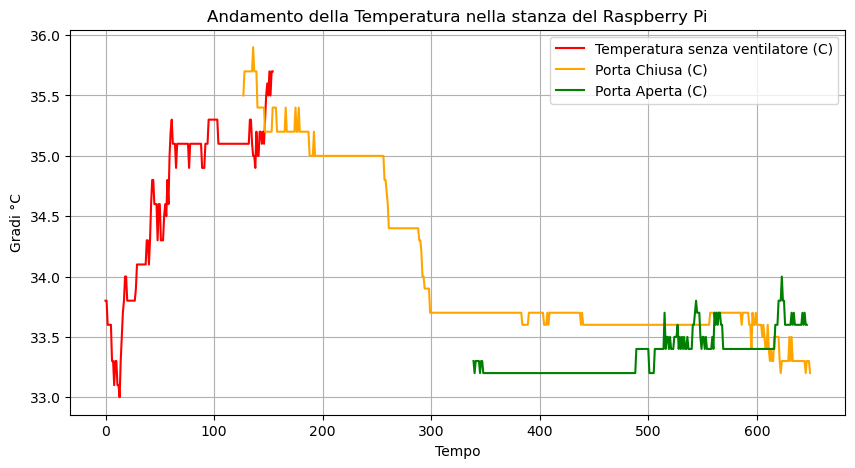

In [94]:
fan_off_df = fan_off [ fan_off['_field'] == 'percepita']
door_closed = cleaned_fan_on_door_closed[ cleaned_fan_on_door_closed['_field'] == 'percepita']
door_open = cleaned_fan_on_door_open[ cleaned_fan_on_door_open['_field'] == 'percepita']



plt.figure(figsize=(10, 5))
plt.plot( fan_off_df['_value'], label='Temperatura senza ventilatore (C)', color='red')
plt.plot( door_closed['_value'], label='Porta Chiusa (C)', color='orange')
plt.plot( door_open['_value'], label='Porta Aperta (C)', color='green')
plt.title('Andamento della Temperatura nella stanza del Raspberry Pi')
plt.xlabel('Tempo')
plt.ylabel('Gradi °C')
plt.grid(True)
plt.legend()
plt.show()

In [96]:
cleaned_fan_on_door_closed.describe()

,Unnamed: 0,table,_value,meteo
count,1569.000000,1569.000000,1569.000000,1569.0
mean,1038.000000,1.000000,33.067240,32.0
std,551.955467,0.816757,1.801494,0.0
min,127.000000,0.000000,30.000000,32.0
25%,519.000000,0.000000,31.000000,32.0
50%,1038.000000,1.000000,33.700000,32.0
75%,1557.000000,2.000000,34.200000,32.0
max,1949.000000,2.000000,35.900000,32.0


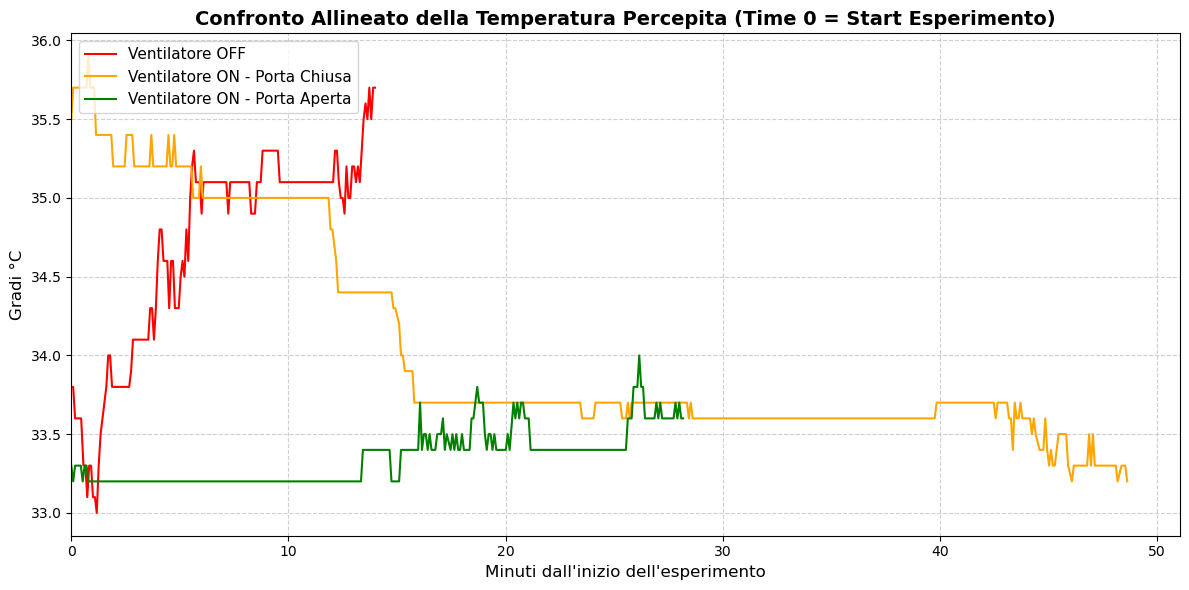

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Sicurezza: Assicuriamoci che _time sia in formato datetime per tutti i DataFrame
fan_off_df['_time'] = pd.to_datetime(fan_off_df['_time'])
door_closed['_time'] = pd.to_datetime(door_closed['_time'])
door_open['_time'] = pd.to_datetime(door_open['_time'])

# 2. CALCOLO DEL TEMPO RELATIVO (Minuti trascorsi dallo start di ciascun test)
# Sottraiamo il valore minimo di _time di OGNI dataframe dal rispettivo _time.
# Poi convertiamo il timedelta in secondi totali e dividiamo per 60 per avere i minuti.
fan_off_df['minuti_trascorsi'] = (fan_off_df['_time'] - fan_off_df['_time'].min()).dt.total_seconds() / 60
door_closed['minuti_trascorsi'] = (door_closed['_time'] - door_closed['_time'].min()).dt.total_seconds() / 60
door_open['minuti_trascorsi'] = (door_open['_time'] - door_open['_time'].min()).dt.total_seconds() / 60

# --- CREAZIONE DEL GRAFICO ALLINEATO ---
plt.figure(figsize=(12, 6))

# Usiamo 'minuti_trascorsi' come asse X invece di '_time'
plt.plot(fan_off_df['minuti_trascorsi'], fan_off_df['_value'], label='Ventilatore OFF', color='red', linewidth=1.5)
plt.plot(door_closed['minuti_trascorsi'], door_closed['_value'], label='Ventilatore ON - Porta Chiusa', color='orange', linewidth=1.5)
plt.plot(door_open['minuti_trascorsi'], door_open['_value'], label='Ventilatore ON - Porta Aperta', color='green', linewidth=1.5)

# --- ABBELLIMENTO ---
plt.title('Confronto Allineato della Temperatura Percepita (Time 0 = Start Esperimento)', fontsize=14, fontweight='bold')
plt.xlabel('Minuti dall\'inizio dell\'esperimento', fontsize=12)
plt.ylabel('Gradi °C', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

# Impostiamo l'asse X in modo che parta esattamente da 0
plt.xlim(left=0)

plt.tight_layout()
plt.show()